In [1]:
import pandas as pd 
import numpy as numpy
from hilary.simulate import Simulator
from hilary.simulate_paired import SimulatorPaired
import numpy as np

2025-04-02 09:43:38.754160: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-02 09:43:38.771366: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1743587018.790920  323559 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1743587018.796885  323559 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-04-02 09:43:38.817210: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

In [2]:
sim=Simulator(model_directory='human_B_heavy')
out=sim.simulate(10000,subtype='mixture')

2025-04-02 09:43:40.839490: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
/home/ec2-user/HILARy/hilary/simulate.py:112: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  self.small = pd.read_csv(mut_directory + "small_spectra.csv.gz")


Generate naive sequences.


Computing energies: 100%|██████████| 1/1 [00:01<00:00,  1.56s/it]


Generate large families.


35it [00:02, 15.14it/s]


Generate small families.


10it [00:04,  2.48it/s]
/home/ec2-user/miniconda3/lib/python3.12/multiprocessing/popen_fork.py:66: RuntimeWarning: Using fork() can cause Polars to deadlock in the child process.
In addition, using fork() with Python in general is a recipe for mysterious
deadlocks and crashes.

The most likely reason you are seeing this error is because you are using the
multiprocessing module on Linux, which uses fork() by default. This will be
fixed in Python 3.14. Until then, you want to use the "spawn" context instead.

See https://docs.pola.rs/user-guide/misc/multiprocessing/ for details.

If you really know what your doing, you can silence this warning with the warning module
or by setting POLARS_ALLOW_FORKING_THREAD=1.

  self.pid = os.fork()
100%|██████████| 2085/2085 [00:00<00:00, 2261.99it/s]/home/ec2-user/miniconda3/lib/python3.12/multiprocessing/popen_fork.py:66: RuntimeWarning: Using fork() can cause Polars to deadlock in the child process.
In addition, using fork() with Python in general 

In [3]:
sim=SimulatorPaired(model_directory_heavy="human_B_heavy",
                    model_directory_light= "human_B_kappa",)
out1=sim.simulate(10000,subtype='mixture')

/home/ec2-user/HILARy/hilary/simulate_paired.py:93: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  self.small = pd.read_csv(mut_directory + "small_spectra.csv.gz")


Generate naive sequences.


Computing energies: 100%|██████████| 1/1 [00:01<00:00,  1.24s/it]


Generate naive sequences.


Computing energies: 100%|██████████| 1/1 [00:00<00:00,  1.38it/s]


...

36it [00:04, 10.22it/s]

40it [00:32,  1.23it/s]


Generate small families.


10it [00:04,  2.41it/s]
 14%|█▍        | 1329/9342 [00:00<00:03, 2091.18it/s]

100%|██████████| 9342/9342 [00:22<00:00, 407.78it/s] 
/home/ec2-user/HILARy/hilary/simulate_paired.py:372: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  .apply(lambda x: str(x[0]).find(x[1]), axis=1)
/home/ec2-user/HILARy/hilary/simulate_paired.py:378: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ].apply(lambda x: (x[0][: x[1]] + x[0][x[2] :]), axis=1)
/home/ec2-user/HILARy/hilary/simulate_paired.py:381: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use

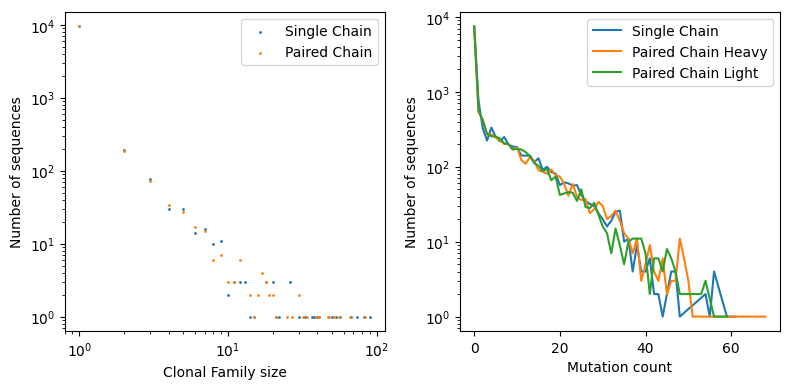

In [4]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,4))
plt.subplot(121)
a,b=np.unique(out.family,return_counts=True)
c,d=np.unique(b,return_counts=True)
plt.scatter(c,d,s=1,label='Single Chain')
a,b=np.unique(out1.family,return_counts=True)
c,d=np.unique(b,return_counts=True)
plt.scatter(c,d,s=1,label='Paired Chain')
plt.legend()
plt.yscale('log')
plt.xscale('log')
plt.ylabel('Number of sequences')
plt.xlabel('Clonal Family size')
plt.subplot(122)
a,b=np.unique(out.mutation_count,return_counts=True)
plt.plot(a,b,label='Single Chain')
a,b=np.unique(out1.mutation_count_heavy,return_counts=True)
plt.plot(a,b,label='Paired Chain Heavy')
a,b=np.unique(out1.mutation_count_light,return_counts=True)
plt.plot(a,b,label='Paired Chain Light')
plt.legend()
plt.yscale('log')
plt.xlabel('Mutation count')
plt.ylabel('Number of sequences')
plt.tight_layout()
plt.show()